# The diffusion equation
Numerical solution of the 1D diffusion problem
$$ \frac{\partial N}{\partial t} =  k \frac{\partial^2 N}{\partial x^2}$$ 
using an explicit scheme

$N(x,t)$ represents the evolution of the dissolved nitrogen (DIN) concentration along the estuary over time

**Claude AI Disclaimer** : I used AI to refine my answers, with some answers being completely AI-generated answers that I refined. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
# constants
SECPERDAY = 86400.
M2KM = 1000

## User defined parameters

In [2]:
# problem parameters
kappa=1.0e3   # Eddy diffusion coefficient [m2 s-1]
dx=500         # X resolution [m]
dt=100         # time step [s]
t0=0.          # initial time
tmax=0.12      # duration of simulation [days]
xmax=10.0e3    # length of the basin [m]

# Parameters of the initial DIN spillage
N0 = 20.       # baseline concentration [mmol/m3]
sigma = 1000.  # width [m]
A = 100.       # amplitude [mmol/m3]

## Initial function and grid specifications
The initial shape of the temperature distribution is a Gaussian peak function

In [3]:
# Spatial shape of the initial DIN concentration
def Gaussian(x):
    y = N0+A*np.exp(-(x/sigma)**2)
    return y

The resulting space-time grid depends on the parameters above. The non-dimensional Courant number must be smaller than 0.5 for conditional stability.

In [4]:
# time axis
NT = int(np.floor(tmax*86400/dt))+1  # number of steps (starts from 0)
# X axis (centred at 0)
x = np.arange(-xmax,xmax,dx)
IM = len(x)             # number of grid points
N = np.zeros([IM,NT])   # the array holding the numerical solution 
print('Grid steps : ',IM)
print('Number of time steps : ',NT)
print('Timestep = ',dt,' s')
print('Max numerical diffusion DX^2/DT = ',dx**2/dt,' m2/s')
print('Physical diffusion = ',kappa,' m2/s')
print('Courant number (diffusion) = ',kappa*dt/(dx**2))

Grid steps :  40
Number of time steps :  104
Timestep =  100  s
Max numerical diffusion DX^2/DT =  2500.0  m2/s
Physical diffusion =  1000.0  m2/s
Courant number (diffusion) =  0.4


## Numerical solution
Note that this code stores the solution at all times in array N for educational purposes. This allows to plot the solution at the different time steps and see how it evolves.

*This method is very inefficient for any application because it uses a lot of memory. In modern computer codes only a few time records are hold in memory. The instantaneous solution is often temporarely stored for computing time averages and then discarded.*

This part of the code is the topic of one question found in the lecture notes

In [5]:
# Compute the numerical solution using a time loop over the number of time steps
N[:,0] = Gaussian(x)    # initial condition

for n in range(NT-1):
    # Question 2
    N[0,n+1]  = N[1,n]
    N[-1,n+1] = N[-2,n]
    # discretization of the second derivative
    rhs = kappa*(N[:-2,n]-2*N[1:-1,n]+N[2:,n])/(dx**2)
    N[1:-1,n+1] = N[1:-1,n] + rhs*dt    

## Plot the result using a matplotlib animation
The animation below displays the evolution of the solution and compares it with the initial condition

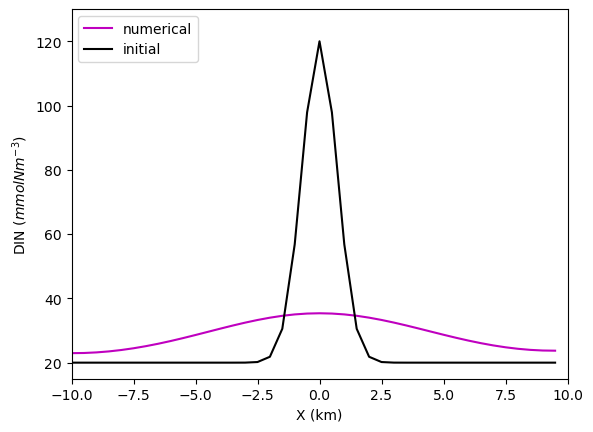

In [6]:
fig, ax = plt.subplots()
# set the axis limits
plt.axis([-xmax/M2KM, xmax/M2KM, N0-5, N0+A+10])
# first plot the initial condition and set the line attributes
sol, = ax.plot(x/M2KM, N[:,0],'m',label='numerical')
line, = ax.plot(x/M2KM, Gaussian(x),'k',label='initial')
ax.set_xlabel('X (km)')
ax.set_ylabel('DIN ($mmol N m^{-3}$)')
plt.legend(loc='upper left')

def animate(i):
    sol.set_ydata(N[:,i])  # update the numerical solution
    return sol,

# create the animation and loop (interval is in ms)
ani = animation.FuncAnimation(
    fig, animate, interval=dt, blit=True, frames=NT, repeat=True)

# display the animation as a javascript object embedded in the notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

# **Exercise 12**

** The numerical solution is similar to Ex. 11 implemented in the notebook diffusion.ipynb. Familiarize yourself with the code and answer the following questions in a modified version of the notebook: 1. Study the numerical solution. Why does the flattening of the peak slow down with time? **

Initially, the peak is sharp, meaning there is a very steep concentration gradient and high curvature. Because the curvature is large, the rate of diffusion is extremely fast. As the mass spreads out, the peak flattens, and the gradients become much smoother. This decrease in spatial curvature directly results in a smaller $\frac{\partial N}{\partial t}$, causing the physical process of diffusion to naturally slow down over time. It is a self-limiting process driven entirely by the steepness of the gradients.

2. Look for the comment #Question 2 in the code. This is a different type of boundary conditions called Neumann conditions (not to be mistaken with von Neumann). How would you describe them? Change the boundary conditions to the ones used in the advection equation (Dirichlet boundary conditions, where the value at the boundary is prescribed). Run this code and compare it with the original: why do you think the Neumann boundary conditions are more realistic?

 N[0,n+1] = N[1,n] and N[-1,n+1] = N[-2,n] implement a zero-gradient Neumann boundary condition.
 
 Instead of setting a specific concentration value at the boundary, this condition forces the concentration at the boundary to perfectly match its immediate inner neighbor. Physically, this represents a "closed" or reflective boundary where there is no flux—meaning no dissolved nitrogen can enter or leave the estuary at these points. 
 
In a closed or semi-closed natural system where you want to track a specific tracer, mass must be conserved. A zero-gradient Neumann condition ensures that all the initial dissolved nitrogen stays within your computational domain. If you use a Dirichlet condition (like setting the boundary permanently to 0), the boundary acts as an infinite "sink." The moment the spreading wave reaches the edge of your grid, the mass will artificially leak out of the model and disappear, violating the conservation of mass for your tracer.

3. The grid parameters determine the stability of the numerical solution and its evolution, based on the physical parameters. In this case, the key parameter is the eddy diffusivity coefficient, which indicates the turbulence of the fluid and how quickly it dissipates the signal. What happens if you double the diffusivity coefficient? [you can adjust the y-axis limits to see the behaviour better]. What would you do to fix it and why?

The scheme is governed by the diffusion Courant number, for the model to remain stable, this number must strictly be 0.5.If you double the eddy diffusivity coefficient (k), you directly double the Courant number. 

If the original model was already running near the stability limit (e.g., $C = 0.4$), doubling $k$ will push $C$ to 0.8. This violates the stability criterion, causing the numerical solution to "blow up." You will see wild, unphysical oscillations in the plot that rapidly grow to infinity rather than a smooth, flattening curve

To fix the instability, you must bring the Courant number back down below the 0.5 threshold. Halve the time step This is the most common and robust fix. Because delta t is in the numerator, halving it perfectly cancels out the doubled k, restoring your original Courant number. The tradeoff is that the simulation will require twice as many computational steps to reach the same end time.

Increase the spatial step (delta x) is squared in the denominator, you could multiply delta x by sqrt{2} to offset the doubled k. However, this is generally not recommended because making your grid blocks larger reduces the spatial resolution and accuracy of your model.Therefore, halving dt is the best approach to maintaining stability without sacrificing the resolution of your spatial gradients.